# GN on jet engine bracket GINN

### Imports and setup

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [2]:
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import trange
import k3d
import time
import copy
import trimesh
import igl
from IPython.display import clear_output

from models.wire import ConditionalWIRE 
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from GINN.shape_boundary_helper import ShapeBoundaryHelper
from util.visualization.utils_mesh import get_mesh
from GINN.ph.ph_manager import PHManager
from models.net_w_partials import NetWithPartials
from training.modular.residuals import ResidualLibrary, ResidualTerm, compute_loss
from training.modular.optimizers import GaussNewton, GaussNewtonNew

torch.manual_seed(0)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### 1) Create model

In [3]:
# model = ConditionalWIRE([4, 32, 32, 32, 1], False, 18, 1, 6)
model = ConditionalWIRE([4, 64, 64, 64, 1], False, 18, 1, 6)
# model = ConditionalWIRE([4, 128, 128, 128, 1], False, 18, 1, 6)



# model = ConditionalWIRE([4, 64, 64, 64, 1], False, 18, 1, 6)
# run_id = "2025_04_25__11_43_40-qc0rhngg"

# model = ConditionalWIRE([4, 32, 32, 32, 1], False, 18, 1, 6)
# run_id = "2025_07_21__13_25_49-rrzz9q06"
# model.load_state_dict(torch.load(f"GINN_models/{run_id}/{run_id}-model.pt", map_location=device)["state_dict"])

## Pre-trained with this script using Adam
# model.load_state_dict(torch.load(f"GINN_models/model-Adam.pt", map_location=device))
# model.load_state_dict(torch.load(f"GINN_models/model-Adam-GN-finetuned.pt", map_location=device))

In [4]:
## Plot
bounds = torch.from_numpy(np.load('Data JEB/bounds.npy')).float()

f = lambda x : model(x, 0.05+torch.zeros([len(x), 1]))
verts, faces = get_mesh(
    f, 
    N=128, 
    device=device,
    bbox_min=bounds[:,0]-0.01,
    bbox_max=bounds[:,1]+0.01,
    chunks=1
)
verts_init, faces_init = verts, faces

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig.display()

/system/apps/userenv/berzins/GINN/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

### 2) Prepare point samples

In [5]:
mesh_env = trimesh.load(os.path.join('Data JEB/411_for_envelope.stl'))

pts_interface_all = torch.from_numpy(np.load('Data JEB/interface_points.npy')).to(device, dtype=torch.float64)
interface_normals_all = torch.from_numpy(np.load('Data JEB/interface_normals.npy')).to(device, dtype=torch.float64)
pts_outside_all = torch.from_numpy(np.load('Data JEB/pts_outside.npy')).to(device, dtype=torch.float64)
pts_inside_all = torch.from_numpy(np.load('Data JEB/pts_inside.npy')).to(device, dtype=torch.float64)
pts_out_far_all = torch.from_numpy(np.load('Data JEB/pts_far_outside.npy')).to(device, dtype=torch.float64)
pts_near_interface_all = torch.from_numpy(np.load('Data JEB/pts_around_interface_outside_env_10mm.npy')).to(device, dtype=torch.float64)
pts_on_env = torch.from_numpy(np.load('Data JEB/pts_on_env.npy')).to(device, dtype=torch.float64)

In [6]:
def subsample_idxs(pts, count):
    return torch.randperm(pts.size(0))[:count]

def subsample(pts, count):
    return pts[subsample_idxs(pts, count)]

def distance_filter(pts, pts_filter, th_dist=0.025, mode="leave_far"):
    dist = torch.min(torch.norm(pts[:, None, :] - pts_filter[None, :, :], dim=2), dim=1)[0]
    if mode=="leave_near":
        return pts[dist < th_dist]
    return pts[dist > th_dist]

def inside_mask(pts, bounds):
    return ((pts >= bounds[:, 0]) & (pts <= bounds[:, 1])).all(dim=1)

def inside_filter(pts, bounds):
    return pts[inside_mask(pts, bounds)]

In [7]:
model = model.double()
bounds = bounds.to(device, dtype=torch.float64)
# pts_surface = sample_model_surface_binsearch(model, torch.zeros([0,3]), bounds=bounds*1.3, z=0.05+torch.zeros([1,1], dtype=torch.float64))
# pts_surface_inside = inside_filter(pts_surface, bounds)
# pts_surface_filtered = distance_filter(pts_surface_inside, subsample(pts_interface_all, 10_000))


# fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
# fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# # fig += k3d.points(pts_surface.cpu(), color=0xff0000, point_size=0.01)
# # fig += k3d.points(pts_surface_inside.cpu(), color=0x0000ff, point_size=0.01)
# # fig += k3d.points(pts_surface_filtered.cpu(), color=0x00ff00, point_size=0.01)
# interface_idxs = subsample_idxs(pts_interface_all, 1000)
# # fig += k3d.points(pts_interface_all[interface_idxs].cpu(), color=0x0000ff, point_size=0.01)
# # fig += k3d.vectors(pts_interface_all[interface_idxs].cpu(), 0.05*interface_normals_all[interface_idxs].cpu(), color=0x0000ff, head_size=0.2, line_width=0.1)
# # fig += k3d.points(subsample(pts_interface_all, 10_000).cpu(), color=0x0000ff, point_size=0.01)
# fig += k3d.mesh(mesh_env.vertices, mesh_env.faces, color=0xbb0000, opacity=0.3)
# fig.display()

### I) Pre-train

In [8]:
# pts_sdf = torch.vstack([pts_inside_all, pts_outside_all, pts_out_far_all, pts_on_env])
# sdf, _, _, _ = igl.signed_distance(pts_sdf.cpu().numpy(), mesh_env.vertices, mesh_env.faces, sign_type=igl.SIGNED_DISTANCE_TYPE_DEFAULT)
# sdf = torch.from_numpy(sdf).to(device=device, dtype=torch.float64)

In [9]:
# res_lib_pre = ResidualLibrary(model)
# res_terms_pre = {
#     "sdf":    ResidualTerm(res_lib_pre._data, 1, pts_sdf, vals=sdf),
# }

In [10]:
# model = model.double()
# params = dict(model.named_parameters())
# z=0.05+torch.zeros([1,1], dtype=torch.float64)

# losses_over_time_pre = {k: [] for k in res_terms_pre.keys()}
# optim = torch.optim.Adam(model.parameters(), 1e-3) ## 1000 for e-3, e-4, e-5 each 
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[1000, 2000], gamma=0.1)

# for i in (pbar:=trange(3000)):
#     optim.zero_grad()
    
#     idxs = subsample_idxs(pts_sdf, 8*4096)
#     res_terms_pre["sdf"].points = pts_sdf[idxs]
#     res_terms_pre["sdf"].vals = sdf[idxs]
    
    
#     ## Evaluate the losses
#     loss, unweighted_losses = compute_loss(params, res_terms_pre, return_unweighted_losses=True)    
#     loss.backward()
    
#     ## Log
#     for k in res_terms_pre.keys():
#         losses_over_time_pre[k].append(unweighted_losses[k].item() if k in unweighted_losses else 0)
#     unweighted_losses_str = " | ".join(f"{key}: {l.item():.2e} ∴{len(res_terms_pre[key].points)}" for key, l in unweighted_losses.items())
#     pbar.set_description(unweighted_losses_str)
#     optim.step()
    
#     if i%100==0:
#         clear_output(wait=True)  # clear the previous plot
#         plt.plot(losses_over_time_pre["sdf"])
#         plt.semilogy()
#         plt.show()


In [11]:
# torch.save(model.state_dict(), f"results/model-Adam-pretrain-3x64.pt")

In [12]:
# model = model.float()
# f = lambda x : model(x, 0.05+torch.zeros([len(x), 1]))
# verts_init, faces_init = get_mesh(
#     f, 
#     N=128, 
#     device=device,
#     bbox_min=bounds[:,0]-0.01,
#     bbox_max=bounds[:,1]+0.01,
#     chunks=1
# )

# fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
# fig += k3d.mesh(verts_init, faces_init, color=0xbbbbbb, side='double', flat_shading=False)
# fig.display()

### 4) Connectedness

In [13]:
model = model.double()

In [14]:
netp = NetWithPartials.create_from_model(model, nz=1, nx=3)
z=0.05+torch.zeros([1,1], dtype=torch.float64)

def is_inside_envelope(a, method="igl"):
    """Remove points that are outside the envelope"""
    if method=="trimesh":
        is_inside_mask = mesh_env.contains(a.cpu().numpy())
    elif method=="igl":
        sdf, _, _, _ = igl.signed_distance(a.cpu().numpy(), mesh_env.vertices, mesh_env.faces, sign_type=igl.SIGNED_DISTANCE_TYPE_DEFAULT)
        is_inside_mask = sdf < 0
    return torch.from_numpy(is_inside_mask)

ph_manager = PHManager(
    mp_pool = None, ## we wont need parallelization
    nx = 3, ## dimension of input
    bounds = bounds, ## bounds of the rectangular domain, list of (min, max) pairs for each coordinate
    netp = netp, ## model in the functional form
    scc_n_grid_points = 64, ## nof grid points along each dimension. this grid is used to perform the discrete PH calculation
    func_inside_envelope = is_inside_envelope, ## a function to mask the points outside the envelope as these would create illegal connections. In the obstacle problem, we do not really need this.
    ph_1_hole_level = 0.1, ## persistence of holes. Ignore this if ph_loss_maxdim=0 (only 0-PH ie connectedness is optimized for)
    ph_loss_target_betti = [1,0,0], ## Target Betti-numers for each dim-PH. Connectedness means 1 for dim=0. Others can be ignored if ph_loss_maxdim=0.
    iso_level = -0.01, ## level defining the boundary. This also enforces the thickness of the thinest feature for an SDF. NOTE  TODO: should be negative??
    ph_loss_sub0_points = False,
    ph_loss_super0_points = False,
    simjeb_root_dir = "", ## leave empty
    problem_str= "", ## leave empty
    ph_loss_maxdim=0, ## connectedness only
    is_density=False, ## is the implicit function a density field? (no for an SDF)
)
print("PH set up complete")

## Reproduce loss calculation
success, loss_scc, _, _ = ph_manager.calc_ph_loss_cripser(z=z) ## PHManager loops over shapes, so it expects a list of latent codes
print(success, loss_scc)

success, x_in = ph_manager.calc_ph_loss_cripser(z=z, return_for_GN=True)
print(success, x_in.shape)
# if success and len(x_in):
#     loss = torch.clamp(0 - f(x_in), max=0.).pow(2).sum()
#     print(loss)

PH set up complete
True tensor(0.0999, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>)
True torch.Size([18, 3])


In [15]:
shape_boundary_helper = ShapeBoundaryHelper(
    nx = 3,
    bounds = bounds,
    netp = netp,
    n_points_surface = 4096//2,
    equidistant_init_grid = 64, ## boolean initial grid for surface points equidistant or same number of points for each dimension
    level_set = 0.0,
    do_uniform_resampling=True,
    surf_pts_lr=0.01, ## learning rate for non-Newton optimizer
    surf_pts_n_iter=10, # iterations of surface flow
    surf_pts_prec_eps=1.0e-3,  ## precision threshold for early stopping surface flow and filtering the points 
    surf_pts_converged_interval=1, ## how often to check the convergence
    surf_pts_use_newton=True, ## whether to use Newton iteration or Adam
    surf_pts_newton_clip=0.15, ## magnitude for clipping the Newton update
    surf_pts_inflate_bounds_amount=0.05, ## inflate the (otherwise tight) bounding box by this fraction
    surf_pts_uniform_n_iter=10, ## nof iterations for repelling the points
    surf_pts_uniform_nof_neighbours=16, ## nof neighbors for knn
    surf_pts_uniform_stepsize=0.75, ## step size for the repelling update; 0.75 worked well with 8 and 16 nns
    surf_pts_uniform_n_iter_reproj=5, ## nof Newton-iterations for reprojecting the points
    surf_pts_uniform_prec_eps=1.0e-3, ## precision for reprojection (similar to above)
    surf_pts_uniform_min_count=1000, ## minimum number of points to redistribute. Less than this is meaningless
    surf_pts_surpress_tqdm=True,
    surf_pts_uniform_reproject_surpress_tqdm=True,
)

## example use
# pts_surface = shape_boundary_helper.get_surface_pts(z=z).data

/system/apps/userenv/berzins/GINN/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


### 4) Design region SDF

In [16]:
## Precompute SDFs
design_region_pts_list = [pts_out_far_all, pts_outside_all, pts_near_interface_all, pts_on_env] ## the point sets we will sample from for the design region loss
design_region_cnt_list = [4096, 4096, 4096, 4096] ## number of points to sample from each set (first used in the training loop; not needed here)
for pts in design_region_pts_list:
    sdf, _, _, _ = igl.signed_distance(pts.cpu().numpy(), mesh_env.vertices, mesh_env.faces, sign_type=igl.SIGNED_DISTANCE_TYPE_DEFAULT)
    pts.sdf = torch.from_numpy(sdf).to(device=device, dtype=torch.float64)

### 5) Residuals

In [17]:
## TODO: write point samplers for each?

In [19]:
res_lib = ResidualLibrary(model)

strain_modified = lambda *args : torch.clamp(res_lib._strain(*args), max=1e3)

## Select the residual terms defining the specific problem
## (incl. weight, points, and (optional) target values)
## Points will be overwritten in each loop. Only specify them here to run the debug code below
pts_eikonal = torch.vstack([subsample(pts_inside_all, 1024), subsample(pts_outside_all, 1024)])
interface_idxs = subsample_idxs(pts_interface_all, 1000)
res_terms = {
    "interface":    ResidualTerm(res_lib._data,             1e+1,   pts_interface_all[interface_idxs], vals=0),
    "design_region":ResidualTerm(res_lib._design_region,    1e+3,   subsample(pts_outside_all, 4096), vals=0.01),
    "eikonal":      ResidualTerm(res_lib._eikonal,          1e+0,   pts_eikonal),
    "strain":       ResidualTerm(strain_modified,           1e-4,   None),
    "connectedness":ResidualTerm(res_lib._connectedness,    1e+3,   x_in.to(device=device, dtype=torch.float64), vals=ph_manager.ISO),
    "normal":       ResidualTerm(res_lib._normal,           1e+1,   pts_interface_all[interface_idxs], vals=interface_normals_all[interface_idxs]),
}

## Works for Adam w/ and w/o strain
# res_terms = {
#     "interface":    ResidualTerm(res_lib._data,             1e+1,   pts_interface_all[interface_idxs], vals=0),
#     "design_region":ResidualTerm(res_lib._design_region,    1e+2,   torch.vstack([subsample(pts_out_far_all, 4096), subsample(pts_outside_all, 4096), subsample(pts_near_interface_all, 4096)])),
#     "eikonal":      ResidualTerm(res_lib._eikonal,          1e+0,   pts_eikonal),
#     "strain":       ResidualTerm(res_lib._strain,           1e-4,   subsample(pts_interface_all, 1)),
#     "connectedness":ResidualTerm(res_lib._connectedness,    1e+2,   x_in.to(device=device, dtype=torch.float64)),
#     "normal":       ResidualTerm(res_lib._normal,           1e+1,   pts_interface_all[interface_idxs], vals=interface_normals_all[interface_idxs]),
# }

## rrzz
#             scale     lambda      weight
# interface   -         1           1
# design      0.1       1           0.1
# eikonal     0.1       1           0.1
# strain      0.001     1           0.001
# connected   -         100         100
# normal      1         1           1


## from ALM ablation (more finely tuned) https://wandb.ai/abra/topginn/runs/im7rt3b6/
#             scale     lambda      weight
# interface   -         10          10
# design      -         1           1
# eikonal     0.01      1           0.01
# strain      0.0005    1           0.0005
# connected   -         10          10
# normal      1         1           1


## Example
# params = dict(model.named_parameters())

# loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
# print("weighted sum:", loss.item())
# for key, l in unweighted_losses.items():
#     print(key, l.item())
    
# weights = {key: res_terms[k].weight for k in res_terms.keys()}

### 6) Train

In [26]:
# model.load_state_dict(torch.load(f"results/model-Adam-pretrain.pt", map_location=device))
model.load_state_dict(torch.load(f"results/model-Adam-pretrain-3x64.pt", map_location=device))
# model.load_state_dict(torch.load(f"results/model-Adam-pretrain-3x128.pt", map_location=device))

<All keys matched successfully>

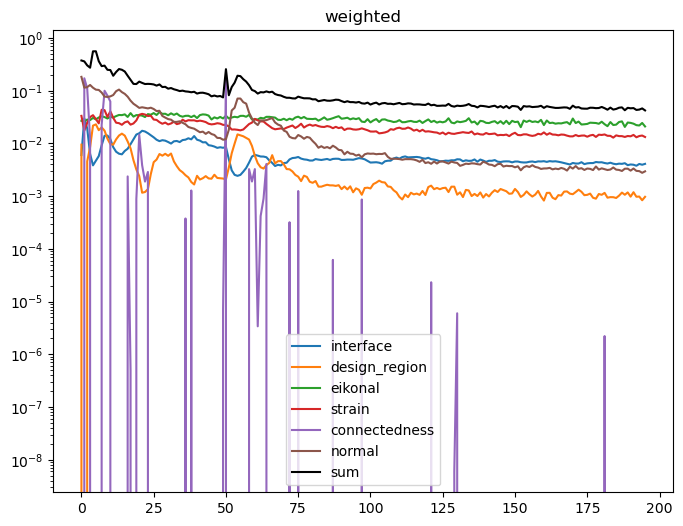

In [28]:
div = 4
params = dict(model.named_parameters())
z=0.05+torch.zeros([1,1], dtype=torch.float64)

losses_over_time = {k: [] for k in res_terms.keys()}
weights_over_time = {k: [] for k in res_terms.keys()}
best_loss = float('inf')
times = []

## line search for minimal surface didnt really help: better per step, but worse per time
## line search did help for implicit shapes
## reg as low as possible w/o leading to instability, e-7
# optim = GaussNewton(model, res_terms, lr=2e-2, regularization=1e-7, do_line_search=1) ## ~1min/it for 3x64 full pts, 20s/it //4 pts,
# optim = GaussNewtonNew(model, res_terms, lr=2e-2, regularization=1e-7, do_line_search=1, do_woodbury=1) ## ~ 2min/it for 3x64 full pts, 3s/it //4 pts
optim = torch.optim.Adam(model.parameters(), 3e-4)
start_time = time.time()
plot_time = start_time
current_time = 0

for i in (pbar:=trange(100_000)):
    if current_time > 120:
        break
    optim.zero_grad()


    ## Sample new points
    with torch.no_grad():
        if "interface" in res_terms.keys():
            interface_idxs = subsample_idxs(pts_interface_all, 4096//div)
            res_terms["interface"].points = pts_interface_all[interface_idxs]
            if "normal" in res_terms.keys():
                res_terms["normal"].points = res_terms["interface"].points
                res_terms["normal"].vals = interface_normals_all[interface_idxs]
        if "eikonal" in res_terms.keys():
            res_terms["eikonal"].points = torch.vstack([subsample(pts_inside_all, 2*1024//div), subsample(pts_outside_all, 2*1024//div)])
        if "design_region" in res_terms.keys():
            ### ZEROS ###
            ## First, sample from three different subsets like in the GINN paper
            idxs_list = [subsample_idxs(pts_all, cnt//div) for pts_all, cnt in zip(design_region_pts_list, design_region_cnt_list)]
            res_terms["design_region"].points = torch.vstack([pts[idxs] for pts, idxs in zip(design_region_pts_list, idxs_list)])
            res_terms["design_region"].vals = torch.hstack([pts.sdf[idxs] for pts, idxs in zip(design_region_pts_list, idxs_list)])
            N_design_region = len(res_terms["design_region"].points)
            ## Second, since the design region loss is inactive for negative points, we can filter these to not waste GN
            mask = res_terms["design_region"].eval(params).squeeze().nonzero().squeeze(-1)
            res_terms["design_region"].points = res_terms["design_region"].points[mask]
            res_terms["design_region"].vals = res_terms["design_region"].vals[mask]
            if len(res_terms["design_region"].points)==0:
                res_terms["design_region"].points = torch.zeros([0,3], dtype=torch.float64)
                res_terms["design_region"].vals = torch.zeros([0,3], dtype=torch.float64)
            else:
                ## Counter-act the point filter
                res_terms["design_region"].weight = 1e+3 / N_design_region * len(res_terms["design_region"].points)
        if "strain" in res_terms.keys():
            # ## Sample via binary search
            # pts_surface = sample_model_surface_binsearch(model, torch.zeros([0,3]), bounds=bounds, z=z)
            ## Sample via Newton flow. Tends to better capture the high-curvature regions.
            pts_surface = shape_boundary_helper.get_surface_pts(z=z)
            pts_surface = torch.zeros([0,3], dtype=torch.float64) if pts_surface is None else pts_surface.data
            pts_surface = pts_surface[is_inside_envelope(pts_surface)]
            pts_surface = distance_filter(pts_surface, subsample(pts_interface_all, 8192), 0.04) ## NOTE: could use a mesh here instead
            res_terms["strain"].points = pts_surface
        if "connectedness" in res_terms.keys():
            success, x_in = ph_manager.calc_ph_loss_cripser(z=z, return_for_GN=True)
            res_terms["connectedness"].points = x_in.to(device=device, dtype=torch.float64)
        
        
    ## Evaluate the losses
    loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
        
    loss.backward()
    optim.step()
    
    ## Log
    for k in res_terms.keys():
        losses_over_time[k].append(unweighted_losses[k].item() if k in unweighted_losses else 0)
        weights_over_time[k].append(res_terms[k].weight if k in unweighted_losses else 0)
    # losses_over_time["weighted_sum"] = loss
     
    current_time = time.time() - start_time
    times.append(current_time)
    
    # if i%10==0:
    if time.time() - plot_time > 5:
        plot_time = time.time()
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8,6))
        for k, v in losses_over_time.items():
            ax.plot(np.array(v)*res_terms[k].weight, label=k)
        weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
        ax.plot(weighted_sum, c='k', label="sum")
        ax.legend()
        ax.semilogy()
        ax.set_title("weighted")
        plt.show()
    
    pbar.display()
    unweighted_losses_str = " | ".join(f"{key}: {l.item():.2e} ∴{len(res_terms[key].points)}" for key, l in unweighted_losses.items())
    pbar.set_description(unweighted_losses_str)

In [22]:
for k in res_terms.keys():
    print(k, "\t", len(res_terms[k].points))

interface 	 1024
design_region 	 173
eikonal 	 1024
strain 	 202
connectedness 	 114
normal 	 1024


In [ ]:
## clip the value on strain
## use a larger model; 
## introduce surface strain later

## ~2000 per residual for minimal surface

## BUNNY:
## sphere sdf pretraining
## 5k eikonal               0.01
## 30k data (interface)     1.0
## 30k normal               1.0
## 20% of 30k was also fine
## No resampling though
## run on nvidia titan 12GB

In [ ]:
success, x_in = ph_manager.calc_ph_loss_cripser(z=z, return_for_GN=True)
print(success, x_in.shape)

True torch.Size([27, 3])


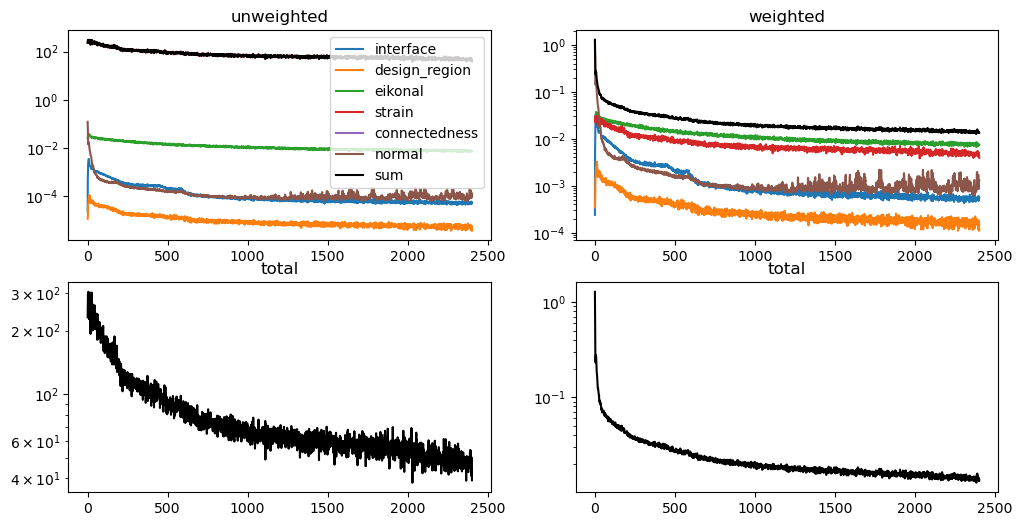

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(12,6))
for k, v in losses_over_time.items():
    axs[0,0].plot(v, label=k)
    axs[0,1].plot(np.array(v)*res_terms[k].weight, label=k)

## Compute total losses
unweighted_sum = np.sum(np.array(list(losses_over_time.values())), axis=0)
axs[0,0].plot(unweighted_sum, c='k', label="sum")
# weighted_sum = np.sum([np.array(losses_over_time[k]) * res_terms[k].weight for k in losses_over_time.keys()], axis=0)
weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
axs[0,1].plot(weighted_sum, c='k', label="sum")

## Format
axs[0,0].semilogy()
axs[0,1].semilogy()
axs[0,0].set_title("unweighted")
axs[0,1].set_title("weighted")
axs[0,0].legend()

## Second row: total losses only
axs[1,0].plot(unweighted_sum, c='k')
axs[1,0].set_title("total")
axs[1,0].semilogy()

axs[1,1].plot(weighted_sum, c='k')
axs[1,1].set_title("total")
axs[1,1].semilogy()

plt.show()

In [29]:
# model = model.float()
f = lambda x : model(x, 0.05+torch.zeros([len(x), 1], dtype=torch.float64) )
verts, faces = get_mesh(
    f, 
    N=128, 
    device=device,
    bbox_min=bounds[:,0]-0.0,
    bbox_max=bounds[:,1]+0.0,
    chunks=1
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
## OLD
# fig += k3d.mesh(verts_init, faces_init, color=0x444444, side='double', flat_shading=False)
## NEW
# fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
## with surface strain colormap
from torch.func import vmap
strains = vmap(res_lib._strain, in_dims=(None, 0))(params, torch.tensor(verts, dtype=torch.float64)).squeeze().detach().cpu()
fig += k3d.mesh(verts, faces, attribute=strains.log10(), side='double', flat_shading=False)

# fig += k3d.points(res_terms["interface"].points.cpu(), color=0xbb00bb, point_size=0.01)
# fig += k3d.points(res_terms["design_region"].points.cpu(), color=0xff0000, point_size=0.01)
# fig += k3d.points(res_terms["strain"].points.cpu(), color=0x0000ff, point_size=0.01)
# fig += k3d.points(x_in.cpu(), color=0xffff00, point_size=0.01)

# pts_surface = shape_boundary_helper.get_surface_pts(z=z).data
# fig += k3d.points(pts_surface.cpu(), color=0x00ff00, point_size=0.01)

# fig += k3d.points(subsample(pts_outside_all, 4096).cpu(), color=0x0000ff, point_size=0.01)
# fig += k3d.points(subsample(pts_out_far_all, 4096).cpu(), color=0x00ff00, point_size=0.01)

# fig += k3d.mesh(mesh_env.vertices, mesh_env.faces, color=0xbb0000, opacity=0.3)

# fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False, attribute=is_inside_envelope(torch.from_numpy(verts)))
fig.display()

Output()

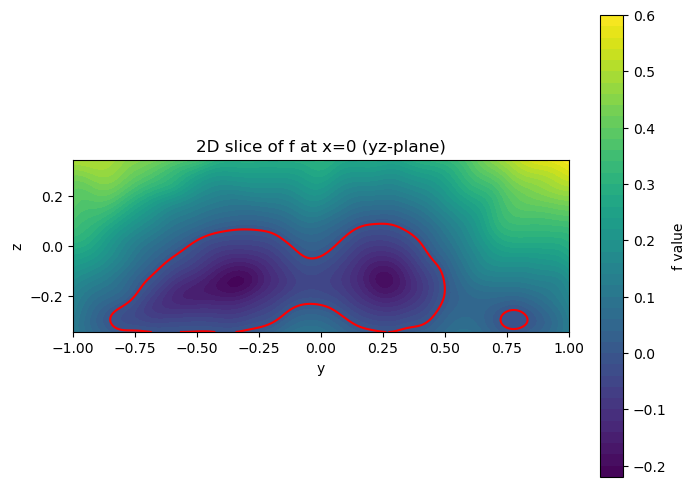

In [ ]:
# Plot a 2D slice of f in the yz-plane at fixed x (e.g., x=0)
y = np.linspace(bounds[1,0].cpu(), bounds[1,1].cpu(), 200)
z_ = np.linspace(bounds[2,0].cpu(), bounds[2,1].cpu(), 200)
Y, Z_ = np.meshgrid(y, z_)
X = np.zeros_like(Y)  # x=0 slice

pts_slice = torch.tensor(np.stack([X, Y, Z_], axis=-1), dtype=torch.float64, device=device).reshape(-1, 3)
vals = f(pts_slice).detach().cpu().numpy().reshape(Y.shape)

plt.figure(figsize=(8,6))
plt.contour(Y, Z_, vals, levels=[0,], colors='r')
plt.contourf(Y, Z_, vals, levels=50, cmap='viridis')
plt.xlabel('y')
plt.ylabel('z')
plt.title('2D slice of f at x=0 (yz-plane)')
plt.colorbar(label='f value')
plt.axis('scaled')
plt.show()

In [25]:
## Save to disk
# key = "folder_name_ie_description"
key = "GNW_3x64_div4_strain[1e-4,max1000]_ph0iso-0.01_linesearch_pre_4096eik_drsdf"
# key = "Adam_3x64_div4_strain[1e-4,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"
os.makedirs(f"results/{key}", exist_ok=True)

torch.save(model.state_dict(), f"results/{key}/model.pt")

import pickle
with open(f'results/{key}/losses_over_time.pkl', 'wb') as f:
    pickle.dump(losses_over_time, f)
    
with open(f'results/{key}/times.pkl', 'wb') as f:
    pickle.dump(times, f)
    
with open(f'results/{key}/weights_over_time.pkl', 'wb') as f:
    pickle.dump(weights_over_time, f)